# Data Analysis of Survey Results - AI Detection and Generation of Jokes
## By: Mirabel Luo and Hayden Chang

In [147]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

## Defining Constants and Preprocessing

In [151]:
GROUND_TRUTH = {
    'Q1': 'AI', 'Q2': 'AI', 'Q3': 'Human', 'Q4': 'AI',
    'Q5': 'AI', 'Q6': 'Human', 'Q7': 'Human', 'Q8': 'AI',
    'Q9': 'AI', 'Q10': 'Human', 'Q11': 'AI', 'Q12': 'AI',
    'Q13': 'Human', 'Q14': 'AI', 'Q15': 'Human', 'Q16': 'Human',
    'Q17': 'AI', 'Q18': 'Human', 'Q19': 'AI', 'Q20': 'AI',
    'Q21': 'Human', 'Q22': 'Human', 'Q23': 'Human', 'Q24': 'Human' 
}

FILES = {
    'Human': 'NIAI_Responses - Form Responses 1.csv',
    'ChatGPT': 'NIAI_Responses - ChatGPT.csv',
    'Claude': 'NIAI_Responses - Claude.csv',
    'Gemini': 'NIAI_Responses - Gemini.csv'
}

# load data 
def load_and_preprocess_data():
    """Loads data using column indices and aligns data types for merging."""
    print("Loading datasets...")
    import os
    if not os.path.exists(FILES['Human']):
        raise FileNotFoundError(f"Cannot find human baseline data: {FILES['Human']}")
        
    df_human = pd.read_csv(FILES['Human'])
    human_results = []
    
    for i in range(1, 25):
        q_prefix = f"Q{i}"
        
        # Access by index: Index 0 is Timestamp. 
        humor_col_idx = (i * 2) - 1
        source_col_idx = (i * 2)
        
        mean_humor = df_human.iloc[:, humor_col_idx].mean()
        mean_source_score = df_human.iloc[:, source_col_idx].mean()
        
        group_guess = "Human" if mean_source_score > 2.5 else "AI"
        
        human_results.append({
            'Question Number': q_prefix,
            'Human_Mean_Humor': mean_humor,
            'Human_Majority_Source_Guess': group_guess
        })
        
    df_master = pd.DataFrame(human_results)
    df_master['Actual_Source'] = df_master['Question Number'].map(GROUND_TRUTH)
    
    # Process Available AI Data
    loaded_models = []
    for model_name in ['ChatGPT', 'Claude', 'Gemini']:
        file_path = FILES[model_name]
        if os.path.exists(file_path):
            try:
                df_ai = pd.read_csv(file_path)
            
                # Converts 1, 2, 3 into "Q1", "Q2", "Q3" 
                df_ai['Question Number'] = 'Q' + df_ai['Question Number'].astype(str)
                
                df_ai = df_ai.rename(columns={
                    'Humor Rating': f'{model_name}_Humor', 
                    'AI/Human Rating': f'{model_name}_Source'
                })
                df_master = pd.merge(df_master, df_ai, on='Question Number', how='left')
                loaded_models.append(model_name)
                print(f"  -> Successfully loaded {model_name} data.")
            except Exception as e:
                print(f"  -> Error loading {model_name}: {e}")
        else:
            print(f"  -> {model_name} data not found (Skipping).")
            
    return df_master, df_human, loaded_models

## Data Visualization and Metrics

In [203]:

def analyze_perception_gap(df_master, model_name):
    """Calculates correlation between Human baseline and an AI model."""
    humor_col = f'{model_name}_Humor'
    clean_df = df_master.dropna(subset=['Human_Mean_Humor', humor_col])
    
    if len(clean_df) < 2:
        return
        
    r, p_value = stats.pearsonr(clean_df['Human_Mean_Humor'], clean_df[humor_col])
    
    print(f"\n[ Perception Correlation: Human vs {model_name} ]")
    print(f"  Pearson r: {r:.3f} | P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  Conclusion: Statistically significant correlation (Similar humor perception).")
    else:
        print("  Conclusion: No significant correlation (Large perception gap).")


def analyze_detection_performance(df_master, rater_name, guess_col):
    """Evaluates source detection accuracy and deception rate with forced labels."""
    clean_df = df_master.dropna(subset=['Actual_Source', guess_col]).copy()
    
    if len(clean_df) == 0:
        return

    if pd.api.types.is_numeric_dtype(clean_df[guess_col]):
        # If the number is > 2.5, it's a guess for Human. Otherwise, AI.
        clean_df[guess_col] = clean_df[guess_col].apply(lambda x: 'Human' if x > 2.5 else 'AI')

    y_true = clean_df['Actual_Source']
    y_pred = clean_df[guess_col]
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="Human", zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label="Human", zero_division=0)
    
    print(f"\n[ Detection Performance: {rater_name} ]")
    print(f"  Accuracy: {acc:.1%} | Precision: {prec:.1%} | Recall: {rec:.1%}")
    
    # Deception Rate
    ai_generated_jokes = clean_df[clean_df['Actual_Source'] == 'AI']
    if len(ai_generated_jokes) > 0:
        fooled_count = (ai_generated_jokes[guess_col] == 'Human').sum()
        deception_rate = fooled_count / len(ai_generated_jokes)
        print(f"  DECEPTION RATE: {deception_rate:.1%} ({fooled_count}/{len(ai_generated_jokes)} AI jokes passed as Human)")
    
    # Visualization
    sns.set_context("notebook", font_scale=1.2)
    
    cm = confusion_matrix(y_true, y_pred, labels=["AI", "Human"])
    tick_labels = ["AI Generated", "Human Authored"]
    
    plt.figure(figsize=(8, 6))
    
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                     annot_kws={"size": 20, "weight": "bold"},
                     cbar_kws={'label': 'Number of Jokes'})
    
    ax.set_xticklabels(tick_labels, fontsize=14)
    ax.set_yticklabels(tick_labels, fontsize=14, rotation=0)
    
    plt.title(f"Source Detection:\n{rater_name}", fontsize=20, pad=15, weight='bold')
    plt.ylabel("Actual Source (Ground Truth)", fontsize=16, labelpad=10, weight='bold')
    plt.xlabel("Predicted Source (Model/Human Guess)", fontsize=16, labelpad=10, weight='bold')
    
    plt.tight_layout()
    plt.show()

def analyze_agreement(df_master, df_human_raw, loaded_models):
    """Compares the variance in humor ratings between AI models and Humans."""
    print("\n[ Inter-Rater Agreement (Variance) ]")
    
    # Human Variance
    humor_cols = [col for col in df_human_raw.columns if 'Rate how humorous' in col or ('Q' in col and 'human or AI' not in col)]
    human_variances = df_human_raw[humor_cols].var()
    mean_human_variance = human_variances.mean()
    print(f"  Average Variance among 10 Human Participants: {mean_human_variance:.2f}")
    
    # AI Variance
    ai_cols = [f"{model}_Humor" for model in loaded_models]
    
    if len(ai_cols) > 1:
        ai_variances = df_master[ai_cols].var(axis=1)
        mean_ai_variance = ai_variances.mean()
        print(f"  Average Variance among {len(loaded_models)} LLMs: {mean_ai_variance:.2f}")
        
        if mean_ai_variance < mean_human_variance:
            print("  Conclusion: LLMs agree with each other MORE than humans do.")
        else:
            print("  Conclusion: LLMs disagree with each other as much/more than humans do.")
    else:
        print("  Note: Need data from at least 2 models to calculate LLM variance.")

def plot_human_nuance_matrix(df_human_raw, ground_truth_dict):
    """
    Plots a 2x4 heatmap showing the distribution of all individual 1-4 Likert 
    responses against the binary ground truth.
    """
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Extract every individual vote
    all_votes = []
    
    # Find all columns related to the AI vs Human guess
    source_cols = [col for col in df_human_raw.columns if 'human or AI' in col]
    
    for col in source_cols:
        # Extract the question number (e.g., 'Q1') from the column text
        # The columns start with "Is the statement in Q1..."
        q_num = col.split('in ')[1].split(' ')[0] 
        
        actual_source = ground_truth_dict.get(q_num)
        
        # Get all the 1-4 ratings from the 10 participants for this question
        ratings = df_human_raw[col].dropna().tolist()
        
        for rating in ratings:
            all_votes.append({'Actual Source': actual_source, 'Rating': rating})
            
    df_votes = pd.DataFrame(all_votes)
    
    # Create the 2x4 Cross-Tabulation Matrix
    matrix_2x4 = pd.crosstab(df_votes['Actual Source'], df_votes['Rating'])
    
    # Ensure all 4 columns exist even if no one voted for a specific option
    for val in [1.0, 2.0, 3.0, 4.0]:
        if val not in matrix_2x4.columns:
            matrix_2x4[val] = 0
            
    # Sort columns and rows to ensure consistent layout
    matrix_2x4 = matrix_2x4[[1.0, 2.0, 3.0, 4.0]]
    matrix_2x4 = matrix_2x4.reindex(['AI', 'Human'])
    
    sns.set_context("notebook", font_scale=1.2)
    plt.figure(figsize=(10, 5))
    
    x_labels = ["1\n(Strongly AI)", "2\n(Slightly AI)", "3\n(Slightly Human)", "4\n(Strongly Human)"]
    y_labels = ["Actual AI", "Actual Human"]
    
    ax = sns.heatmap(matrix_2x4, annot=True, fmt='d', cmap='magma', 
                     annot_kws={"size": 18, "weight": "bold"},
                     cbar_kws={'label': 'Total Individual Votes'})
    
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_yticklabels(y_labels, fontsize=14, rotation=0)
    
    plt.title("Human Perception Gradient", fontsize=18, pad=15, weight='bold')
    plt.ylabel("Ground Truth", fontsize=14, weight='bold', labelpad=10)
    plt.xlabel("Participant Rating", fontsize=14, weight='bold', labelpad=10)
    
    plt.tight_layout()
    plt.show()


Loading datasets...
  -> Successfully loaded ChatGPT data.
  -> Successfully loaded Claude data.
  -> Successfully loaded Gemini data.

=== RUNNING DETECTION & DECEPTION ANALYSIS ===

[ Detection Performance: Human Baseline (Majority Vote) ]
  Accuracy: 62.5% | Precision: 66.7% | Recall: 50.0%
  DECEPTION RATE: 25.0% (3/12 AI jokes passed as Human)


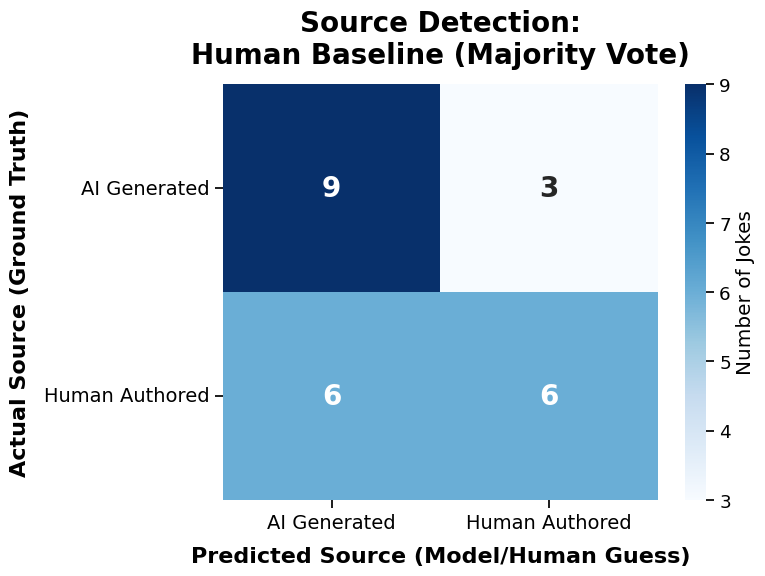


[ Detection Performance: ChatGPT Model ]
  Accuracy: 25.0% | Precision: 12.5% | Recall: 8.3%
  DECEPTION RATE: 58.3% (7/12 AI jokes passed as Human)


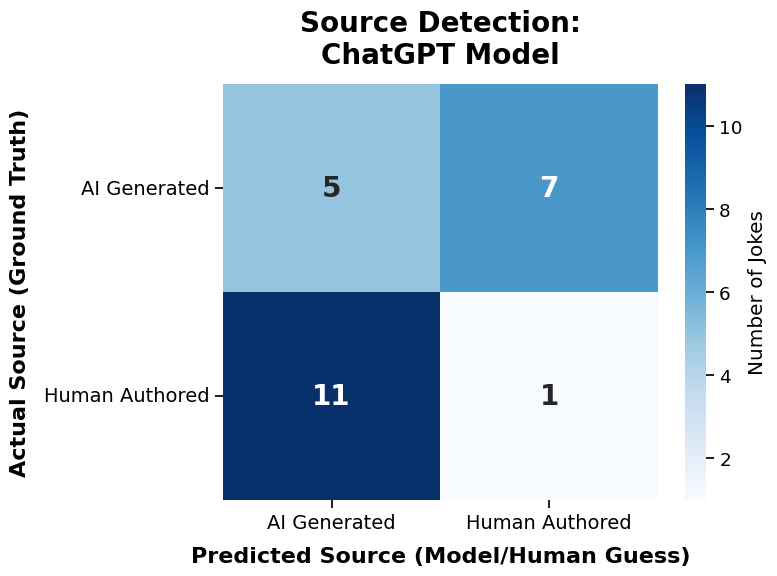


[ Detection Performance: Claude Model ]
  Accuracy: 33.3% | Precision: 0.0% | Recall: 0.0%
  DECEPTION RATE: 33.3% (4/12 AI jokes passed as Human)


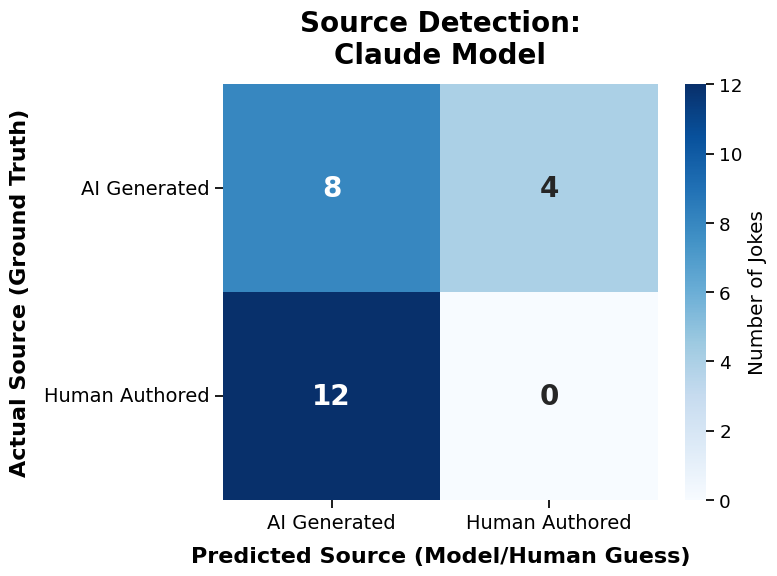


[ Detection Performance: Gemini Model ]
  Accuracy: 58.3% | Precision: 62.5% | Recall: 41.7%
  DECEPTION RATE: 25.0% (3/12 AI jokes passed as Human)


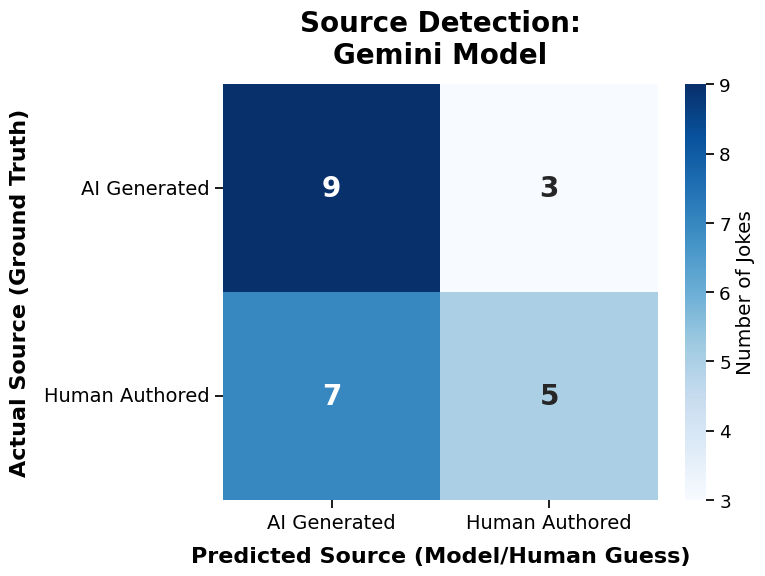

In [157]:
df_master, df_human_raw, loaded_models = load_and_preprocess_data()

print("\n=== RUNNING DETECTION & DECEPTION ANALYSIS ===")
# Run for Human Baseline
analyze_detection_performance(df_master, "Human Baseline (Majority Vote)", "Human_Majority_Source_Guess")
# Run for each loaded AI model
for model in loaded_models:
    analyze_detection_performance(df_master, f"{model} Model", f"{model}_Source")


=== RUNNING INTER-RATER AGREEMENT ===

[ Inter-Rater Agreement (Variance) ]
  Average Variance among 10 Human Participants: 1.40
  Average Variance among 3 LLMs: 0.22
  Conclusion: LLMs agree with each other MORE than humans do.

=== GENERATING HUMAN NUANCE MATRIX ===


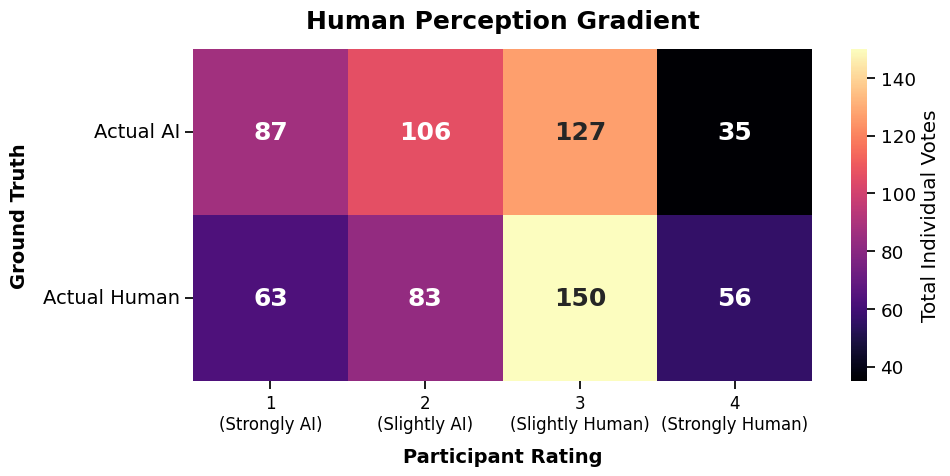

In [159]:
    print("\n=== RUNNING INTER-RATER AGREEMENT ===")
analyze_agreement(df_master, df_human_raw, loaded_models)
    
print("\n=== GENERATING HUMAN NUANCE MATRIX ===")
# Call the nuanced 2x4 matrix for human responses
# TODO: make function for AI nuance matrix
plot_human_nuance_matrix(df_human_raw, GROUND_TRUTH)

In [161]:
from sklearn.metrics import roc_curve, auc

# Perception Scatter Plot
def plot_perception_scatter(df_master, model_name):
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    humor_col = f'{model_name}_Humor'
    
    sns.scatterplot(data=df_master, x='Human_Mean_Humor', y=humor_col, 
                    hue='Actual_Source', palette={'Human': '#2ecc71', 'AI': '#e74c3c'},
                    s=100, edgecolor='black', alpha=0.8)
    
    plt.plot([1, 5], [1, 5], 'k--', zorder=0, label='Perfect Agreement (y=x)')
    plt.title(f"Humor Perception Alignment: Human vs. {model_name}", weight='bold')
    plt.xlabel("Human Mean Humor Rating (1-5)")
    plt.ylabel(f"{model_name} Humor Rating (1-5)")
    plt.xlim(0.5, 5.5)
    plt.ylim(0.5, 5.5)
    plt.legend(title="Joke Source")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Generation Quality Boxplot
def plot_generation_quality(df_master):
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    sns.boxplot(data=df_master, x='Actual_Source', y='Human_Mean_Humor', 
                palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, width=0.5)
    
    sns.stripplot(data=df_master, x='Actual_Source', y='Human_Mean_Humor', 
                  color='black', alpha=0.5, size=8, jitter=True)
    
    plt.title("Generation Quality: Are AI Jokes as Funny as Human Jokes?", weight='bold')
    plt.xlabel("Actual Joke Source")
    plt.ylabel("Funniness Rating (Scored by Humans)")
    plt.tight_layout()
    plt.show()


# Source Detection ROC Curve
def plot_source_detection_roc(df_master, loaded_models):
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    # Ground truth: Convert 'Human' to 1 and 'AI' to 0 for the math to work
    y_true = df_master['Actual_Source'].map({'Human': 1, 'AI': 0})
    
    colors = ['#3498db', '#9b59b6', '#e67e22'] # Blue, Purple, Orange
    
    for i, model in enumerate(loaded_models):
        source_col = f'{model}_Source'
        
        # We need the RAW numeric 1-4 guesses to draw a curve
        if source_col in df_master.columns:
            # We map 1-4 onto a 0.0 - 1.0 probability scale
            y_scores = (df_master[source_col].astype(float) - 1) / 3 
            
            fpr, tpr, _ = roc_curve(y_true, y_scores)
            roc_auc = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, color=colors[i], lw=2, 
                     label=f'{model} (AUC = {roc_auc:.2f})')
            
    # Add random guessing line
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    
    plt.title('ROC Curve: Source Detection Accuracy', weight='bold')
    plt.xlabel('False Positive Rate (Incorrectly labeling AI as Human)')
    plt.ylabel('True Positive Rate (Correctly identifying Human)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Correlation Matrix
def plot_correlation_matrix(df_master, loaded_models):
    import numpy as np
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    # Select only the humor rating columns for correlation
    cols_to_correlate = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    
    # Calculate the Pearson correlation matrix
    corr_matrix = df_master[cols_to_correlate].corr()
    
    # Clean up the labels for the graph
    clean_labels = ['Human Baseline'] + loaded_models
    corr_matrix.index = clean_labels
    corr_matrix.columns = clean_labels
    
    # Create a mask so we only show the bottom triangle of the matrix (cleaner look)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Draw the heatmap
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
                vmin=-1, vmax=1, center=0, square=True, 
                linewidths=.5, cbar_kws={"shrink": .8, 'label': 'Pearson Correlation (r)'},
                annot_kws={"size": 16, "weight": "bold"})
    
    plt.title("Humor Perception Correlation Matrix", weight='bold', pad=15, fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(rotation=0, fontsize=14)
    plt.tight_layout()
    plt.show()

# Intersection Analysis 
def plot_intersection_analysis(df_master, model_name):
    df_temp = df_master.copy()
    humor_col = f'{model_name}_Humor'
    source_col = f'{model_name}_Source'
    
    # Calculate absolute error (Difference from human average)
    df_temp['Humor_Error'] = abs(df_temp[humor_col] - df_temp['Human_Mean_Humor'])
    
    # Check if they got the source right
    model_guesses = df_temp[source_col].apply(lambda x: 'Human' if float(x) > 2.5 else 'AI')
    df_temp['Source_Guess_Correct'] = (model_guesses == df_temp['Actual_Source'])
    df_temp['Source_Guess_Correct'] = df_temp['Source_Guess_Correct'].map({True: 'Correctly Identified', False: 'Incorrectly Identified'})
    
    plt.figure(figsize=(9, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    # Added hue='Source_Guess_Correct' and legend=False
    sns.violinplot(data=df_temp, x='Source_Guess_Correct', y='Humor_Error', 
                   hue='Source_Guess_Correct', legend=False,
                   inner="quartile", palette="muted")
    
    sns.swarmplot(data=df_temp, x='Source_Guess_Correct', y='Humor_Error', 
                  color="black", alpha=0.6, size=7)
    
    plt.title(f"Intersection: Does Knowing the Source Improve Humor Rating?\n({model_name})", weight='bold')
    plt.xlabel("Model's Source Identification Accuracy")
    plt.ylabel("Humor Error\n(Difference from Human Average)")
    plt.tight_layout()
    plt.show()

In [163]:
df_master, df_human_raw, loaded_models = load_and_preprocess_data()

Loading datasets...
  -> Successfully loaded ChatGPT data.
  -> Successfully loaded Claude data.
  -> Successfully loaded Gemini data.



Generating Plot 1: Generation Quality...


/var/folders/4n/kg_g5q5x74s1jbw8wpr9rjcm0000gp/T/ipykernel_23670/1890633526.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Actual_Source', y='Human_Mean_Humor',


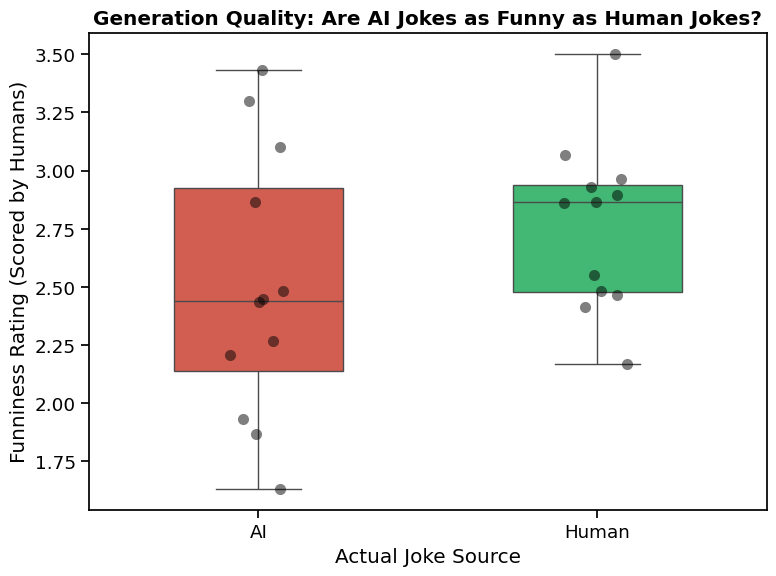

In [165]:
 # --- PLOT 1: Generation Quality ---
print("\nGenerating Plot 1: Generation Quality...")
plot_generation_quality(df_master)


Generating Plot 2: Perception Alignment...


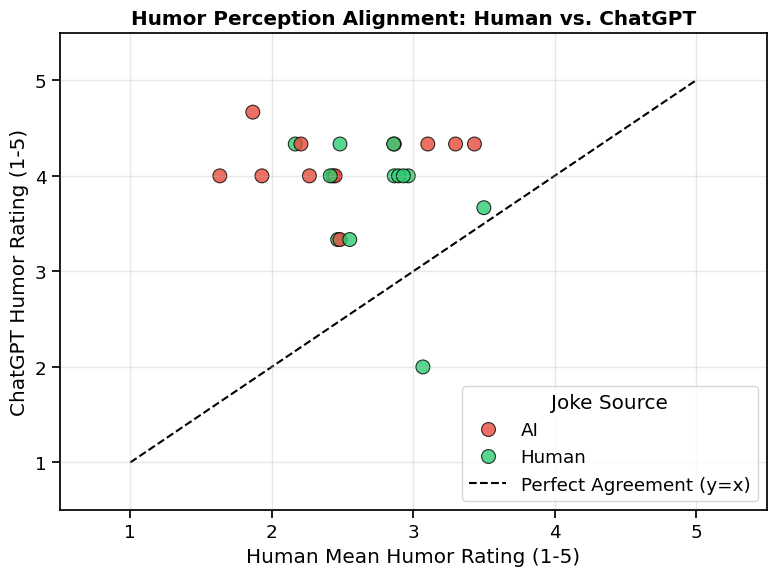

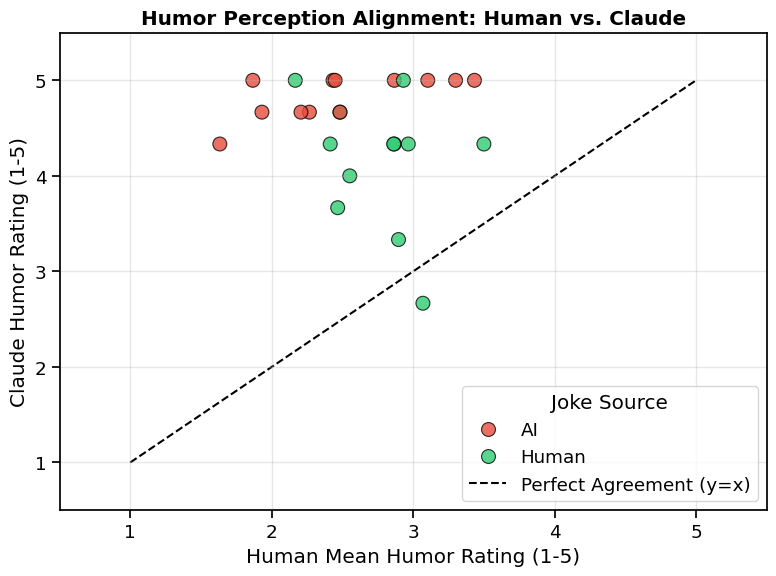

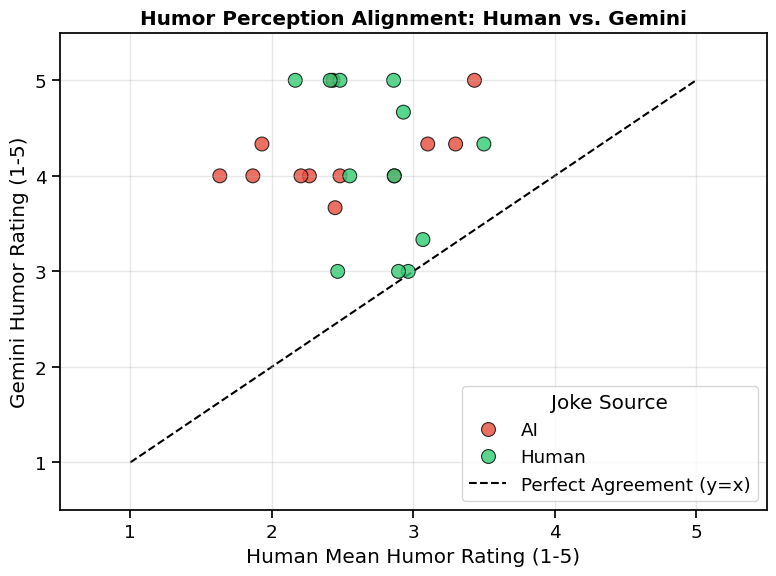

In [167]:
# --- PLOT 2: Perception Alignment Scatter ---
print("\nGenerating Plot 2: Perception Alignment...")
for model in loaded_models:
    plot_perception_scatter(df_master, model)


Generating Plot 3: Humor Correlation Matrix...


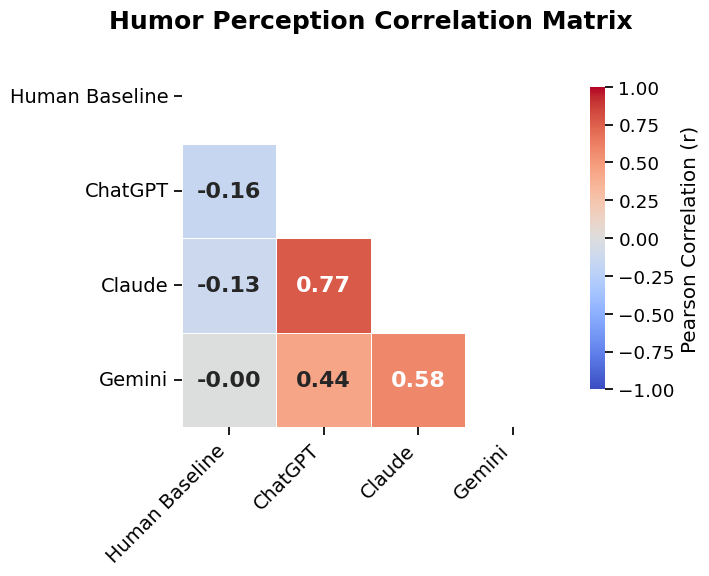

In [169]:
# PLOT 3: Humor Correlation Matrix ---
print("\nGenerating Plot 3: Humor Correlation Matrix...")
# Shows how well Human, ChatGPT, and Gemini all align with each other!
plot_correlation_matrix(df_master, loaded_models)
        


Generating Plot 4: ROC Curve (All Models)...


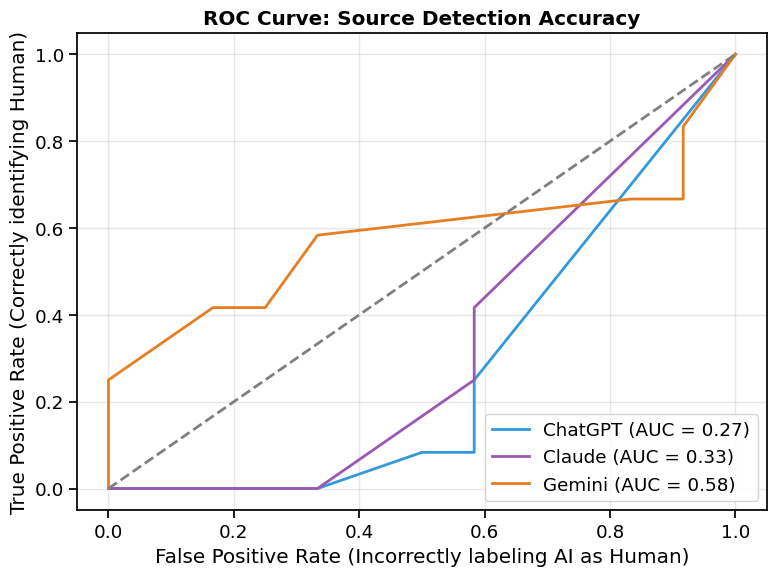

In [171]:
 # --- PLOT 4: Source Detection ROC Curve ---
print("\nGenerating Plot 4: ROC Curve (All Models)...")
plot_source_detection_roc(df_master, loaded_models)

In [175]:
def plot_item_agreement_heatmap(df_master, loaded_models):
    plt.figure(figsize=(15, 5))
    sns.set_context("notebook", font_scale=1.1)
    
    # Grab just the humor rating columns
    cols_to_plot = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    
    # Set the Question Number as the index so it becomes the X-axis
    df_heat = df_master.set_index('Question Number')[cols_to_plot]
    
    # Clean up row labels for the graph
    df_heat.columns = ['Human Baseline'] + loaded_models
    
    # Transpose (.T) so Raters are rows and Questions are columns
    ax = sns.heatmap(df_heat.T, cmap='magma', annot=True, fmt=".1f", 
                     annot_kws={"size": 12, "weight": "bold"},
                     cbar_kws={'label': 'Humor Rating (1-5)'},
                     linewidths=.5)
    
    plt.title("Item-by-Item Agreement: How Funny was Each Joke?", weight='bold', pad=15, fontsize=18)
    plt.xlabel("Joke ID (Question Number)", weight='bold', labelpad=10)
    plt.ylabel("Rater", weight='bold', labelpad=10)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()


Generating Plot 6: Item-by-Item Agreement Heatmap...


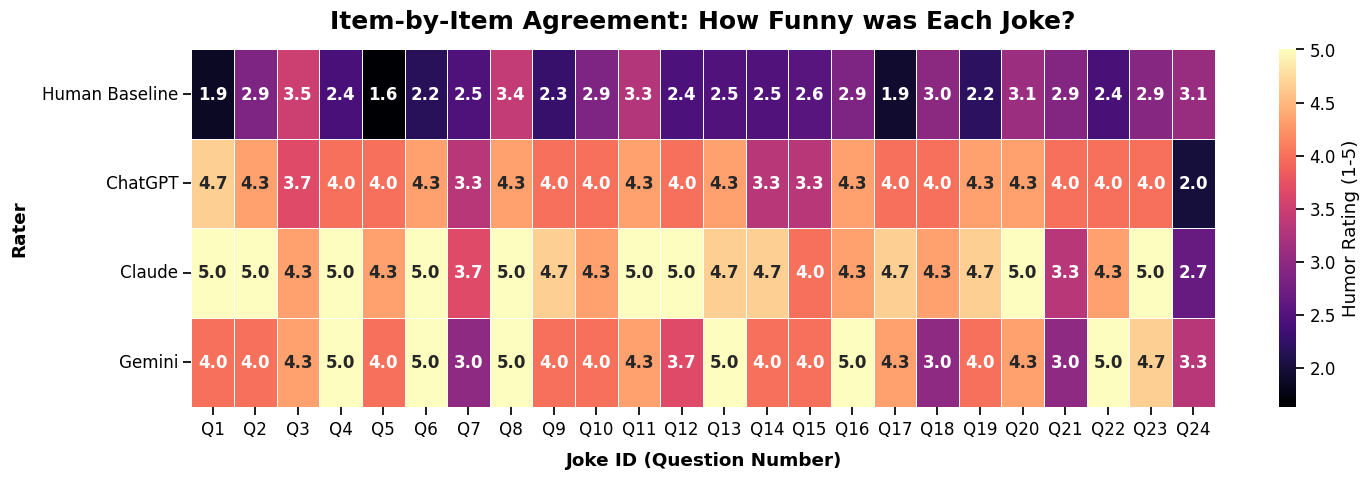

In [177]:
# Plot 6: Item-by-Item Agreement
print("\nGenerating Plot 6: Item-by-Item Agreement Heatmap...")
plot_item_agreement_heatmap(df_master, loaded_models)

In [179]:
def plot_item_divergence_bar(df_master, loaded_models):
    # We need at least 2 entities to have a disagreement!
    cols_to_compare = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    
    if len(cols_to_compare) < 2:
        print("Need at least 1 AI model loaded to calculate divergence.")
        return
        
    df_temp = df_master.copy()
    
    # Calculate the variance across the raters for EACH row (question)
    df_temp['Rating_Variance'] = df_temp[cols_to_compare].var(axis=1)
    
    plt.figure(figsize=(14, 6))
    sns.set_context("notebook", font_scale=1.1)
    
    # Bar plot color-coded by who actually wrote the joke
    sns.barplot(data=df_temp, x='Question Number', y='Rating_Variance', 
                hue='Actual_Source', dodge=False, 
                palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, edgecolor='black')
    
    plt.title("Humor Disagreement: Which Jokes Caused the Most Confusion?", weight='bold', fontsize=18, pad=15)
    plt.ylabel("Variance (Disagreement Level)", weight='bold')
    plt.xlabel("Joke ID (Question Number)", weight='bold')
    plt.xticks(rotation=45)
    plt.legend(title="Actual Joke Source")
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

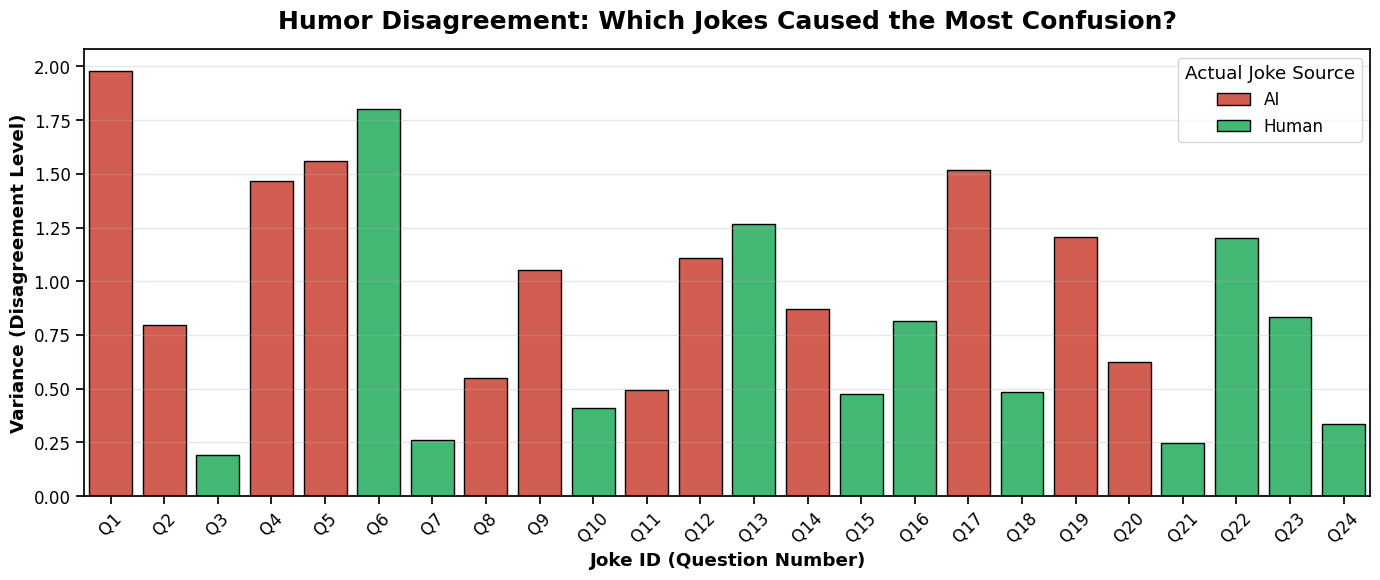

In [181]:
# Plot 7: Item Divergence Bar
plot_item_divergence_bar(df_master, loaded_models)

In [189]:
def plot_spearman_correlation_matrix(df_master, loaded_models):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    cols_to_correlate = ['Human_Mean_Humor'] + [f"{model}_Humor" for model in loaded_models]
    corr_matrix = df_master[cols_to_correlate].corr(method='spearman')
    
    clean_labels = ['Human Baseline'] + loaded_models
    corr_matrix.index = clean_labels
    corr_matrix.columns = clean_labels
    
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", 
                vmin=-1, vmax=1, center=0, square=True, 
                linewidths=.5, cbar_kws={"shrink": .8, 'label': "Spearman's ρ"},
                annot_kws={"size": 18, "weight": "bold"})
    
    plt.title("Relative Humor Agreement Matrix\n(Spearman Rank Correlation)", weight='bold', pad=15, fontsize=18)
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(rotation=0, fontsize=14)
    plt.tight_layout()
    plt.show()

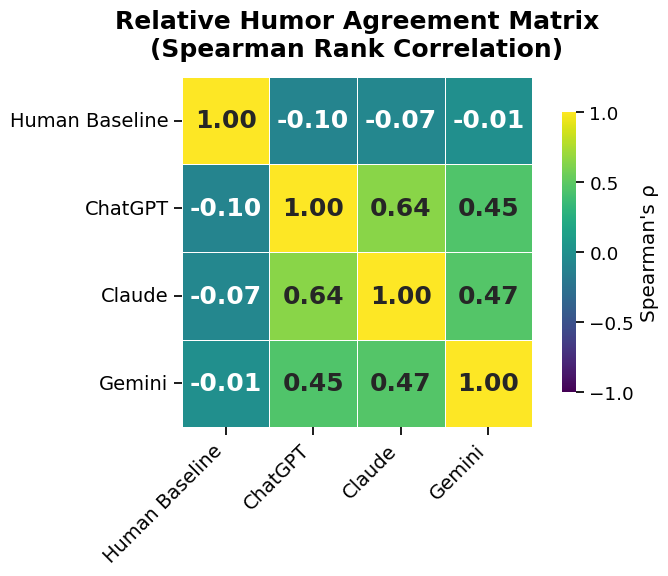

In [191]:
plot_spearman_correlation_matrix(df_master, loaded_models)

In [205]:
def plot_perceived_source_bias(df_master, model_name):
    import scipy.stats as stats
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Route the correct columns based on who we are evaluating
    if model_name == 'Human Baseline':
        humor_col = 'Human_Mean_Humor'
        guess_col = 'Human_Majority_Source_Guess'
    else:
        humor_col = f'{model_name}_Humor'
        guess_col = f'{model_name}_Source'
        
    df_temp = df_master.dropna(subset=[humor_col, guess_col]).copy()
    
    # Ensure the guess column is text ('Human' or 'AI')
    if pd.api.types.is_numeric_dtype(df_temp[guess_col]):
        df_temp['Guessed_Source'] = df_temp[guess_col].apply(lambda x: 'Human' if float(x) > 2.5 else 'AI')
    else:
        df_temp['Guessed_Source'] = df_temp[guess_col]
        
    # Statistical T-Test
    ai_guesses = df_temp[df_temp['Guessed_Source'] == 'AI'][humor_col]
    human_guesses = df_temp[df_temp['Guessed_Source'] == 'Human'][humor_col]
    
    # Only run the t-test if we have at least one guess in both categories
    if len(ai_guesses) > 0 and len(human_guesses) > 0:
        t_stat, p_val = stats.ttest_ind(ai_guesses, human_guesses, nan_policy='omit')
        p_val_str = f"p = {p_val:.3f}"
        
        print(f"\n[ The 'Turing Bias' T-Test: {model_name} ]")
        print(f"  Avg Humor when guessed 'AI':    {ai_guesses.mean():.2f}")
        print(f"  Avg Humor when guessed 'Human': {human_guesses.mean():.2f}")
        if p_val < 0.05:
            print("  Conclusion: SIGNIFICANT BIAS. Scores change based on assumed author.")
        else:
            print("  Conclusion: NO SIGNIFICANT BIAS. Assumed author does not affect the score.")
    else:
        p_val_str = "N/A (Missing Data)"

    # Plots!
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", font_scale=1.2)
    
    sns.violinplot(data=df_temp, x='Guessed_Source', y=humor_col, 
                   hue='Guessed_Source', legend=False,
                   palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, inner="quartile")
    
    sns.swarmplot(data=df_temp, x='Guessed_Source', y=humor_col, 
                  color="black", alpha=0.6, size=7)
    
    plt.title(f"The 'Turing Bias': {model_name}\nDoes perceived author affect the score?", weight='bold', pad=15)
    plt.xlabel("What the Rater THOUGHT the Source Was", weight='bold')
    plt.ylabel("Given Humor Rating (1-5)", weight='bold')
    plt.ylim(0.5, 5.5)
    
    # Add a text annotation for the p-value on the chart
    plt.text(0.5, 0.05, f"T-Test: {p_val_str}", transform=plt.gca().transAxes, 
             ha='center', va='bottom', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.tight_layout()
    plt.show()


Generating Plot 8: Perceived Source Bias (Turing Bias)...

[ The 'Turing Bias' T-Test: Human Baseline ]
  Avg Humor when guessed 'AI':    2.40
  Avg Humor when guessed 'Human': 3.02
  Conclusion: SIGNIFICANT BIAS. Scores change based on assumed author.


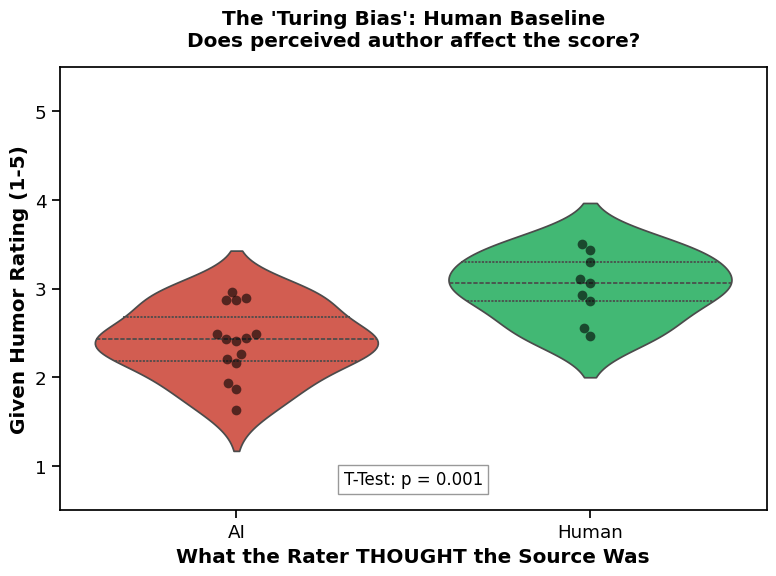


[ The 'Turing Bias' T-Test: ChatGPT ]
  Avg Humor when guessed 'AI':    4.00
  Avg Humor when guessed 'Human': 3.87
  Conclusion: NO SIGNIFICANT BIAS. Assumed author does not affect the score.


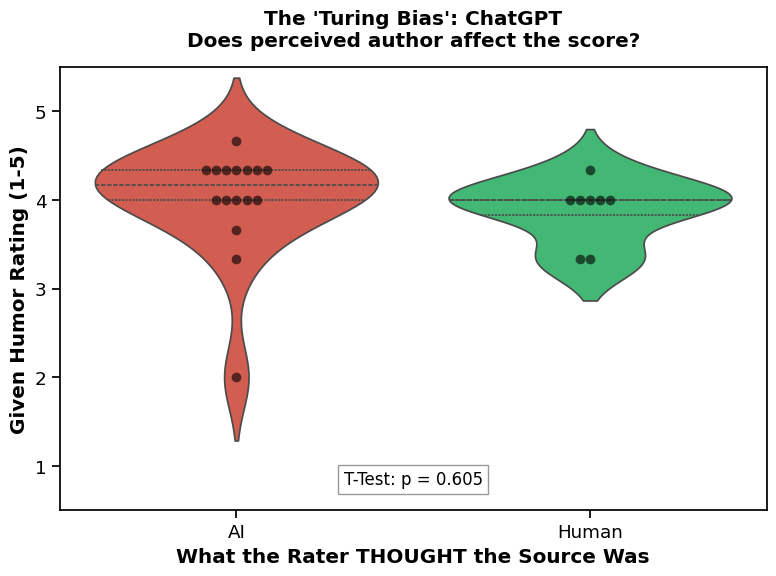


[ The 'Turing Bias' T-Test: Claude ]
  Avg Humor when guessed 'AI':    4.48
  Avg Humor when guessed 'Human': 4.58
  Conclusion: NO SIGNIFICANT BIAS. Assumed author does not affect the score.


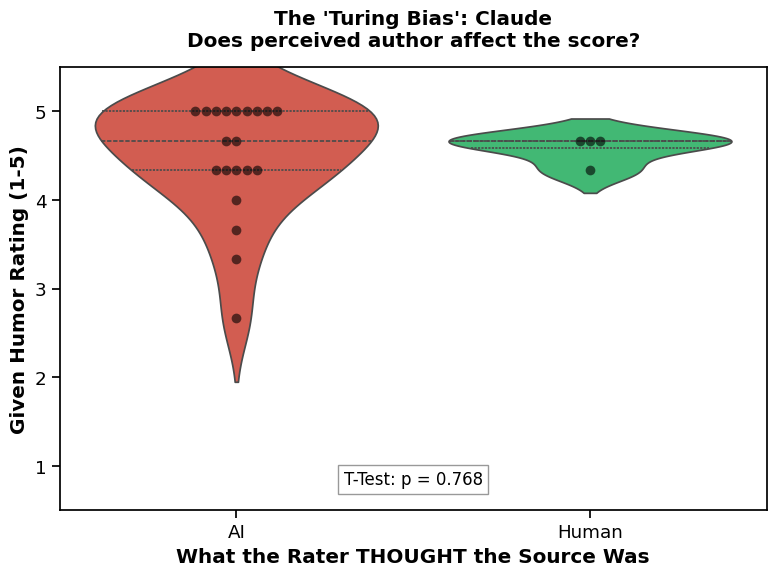


[ The 'Turing Bias' T-Test: Gemini ]
  Avg Humor when guessed 'AI':    4.42
  Avg Humor when guessed 'Human': 3.67
  Conclusion: SIGNIFICANT BIAS. Scores change based on assumed author.


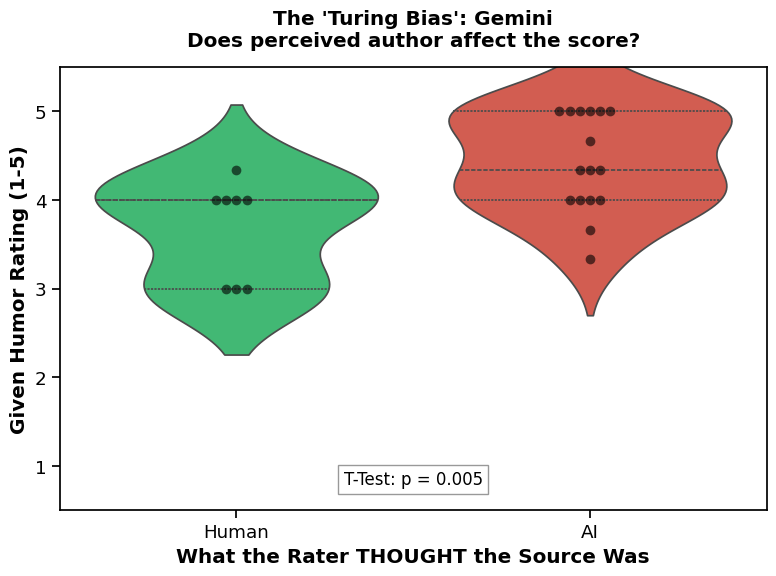


=== VISUAL ANALYSIS COMPLETE ===


In [197]:

# --- PLOT 8: The "Turing Bias" (Perceived Source Bias) ---
print("\nGenerating Plot 8: Perceived Source Bias (Turing Bias)...")

# Run it for the Human Baseline first
plot_perceived_source_bias(df_master, 'Human Baseline')

# Run it for all loaded AI models
for model in loaded_models:
    plot_perceived_source_bias(df_master, model)
    
print("\n=== VISUAL ANALYSIS COMPLETE ===")

Generating Combined Perceived Source Bias (Turing Bias) Matrix...


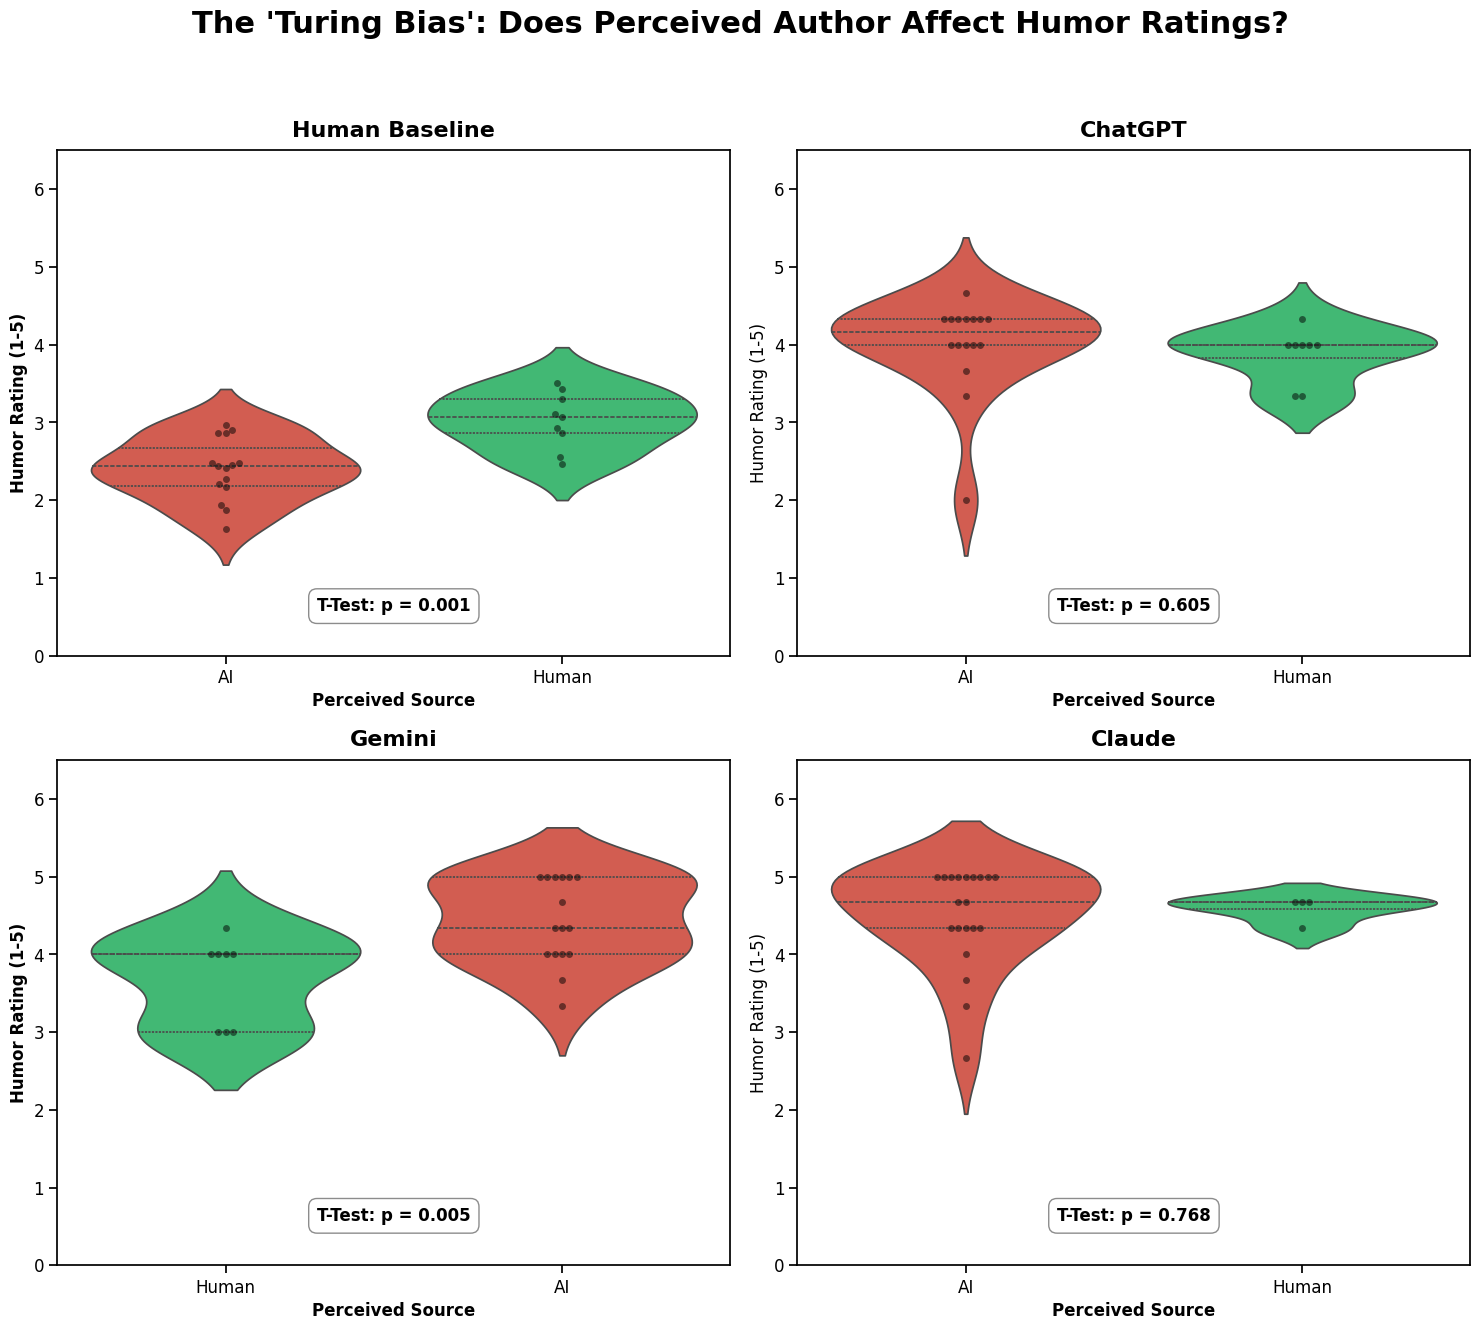


=== VISUAL ANALYSIS COMPLETE ===


In [217]:
# same as above but put all 4 plots into 1 big plot
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_perceived_source_bias_subplot(df_master, model_name, ax):
    """Modified version to plot on a specific axis for subplots with increased y-axis padding."""
    # Route the correct columns
    if model_name == 'Human Baseline':
        humor_col = 'Human_Mean_Humor'
        guess_col = 'Human_Majority_Source_Guess'
    else:
        humor_col = f'{model_name}_Humor'
        guess_col = f'{model_name}_Source'
        
    if humor_col not in df_master.columns or guess_col not in df_master.columns:
        ax.set_title(f"{model_name} (Data Not Found)")
        return

    df_temp = df_master.dropna(subset=[humor_col, guess_col]).copy()
    
    # Label conversion
    if pd.api.types.is_numeric_dtype(df_temp[guess_col]):
        df_temp['Guessed_Source'] = df_temp[guess_col].apply(lambda x: 'Human' if float(x) > 2.5 else 'AI')
    else:
        df_temp['Guessed_Source'] = df_temp[guess_col]
        
    # Stats calculation
    ai_guesses = df_temp[df_temp['Guessed_Source'] == 'AI'][humor_col]
    human_guesses = df_temp[df_temp['Guessed_Source'] == 'Human'][humor_col]
    
    p_val_str = "N/A"
    if len(ai_guesses) > 1 and len(human_guesses) > 1:
        t_stat, p_val = stats.ttest_ind(ai_guesses, human_guesses, nan_policy='omit')
        p_val_str = f"p = {p_val:.3f}"

    # Drawing the Plot
    sns.violinplot(data=df_temp, x='Guessed_Source', y=humor_col, ax=ax,
                   hue='Guessed_Source', legend=False,
                   palette={'Human': '#2ecc71', 'AI': '#e74c3c'}, inner="quartile")
    
    sns.swarmplot(data=df_temp, x='Guessed_Source', y=humor_col, ax=ax,
                  color="black", alpha=0.5, size=5)
    
    # --- ADJUSTMENTS: Increased Y-limit and Padding ---
    ax.set_title(f"{model_name}", weight='bold', size=16, pad=10)
    ax.set_xlabel("Perceived Source", weight='bold', size=12)
    # Set y-axis to 0-6 to provide "headroom" for the T-test box and avoid cutoff
    ax.set_ylim(0, 6.5) 
    ax.set_ylabel("Humor Rating (1-5)", weight='bold' if model_name in ['Human Baseline', 'Gemini'] else 'normal', size=12)
    
    # Annotation - Moved higher and styled for visibility
    ax.text(0.5, 0.08, f"T-Test: {p_val_str}", transform=ax.transAxes, 
             ha='center', va='bottom', fontsize=12, weight='bold',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

# --- MAIN EXECUTION: 2x2 GRID ---
# Increased figsize height (from 12 to 14) to prevent vertical crowding
fig, axes = plt.subplots(2, 2, figsize=(15, 14))
sns.set_context("notebook", font_scale=1.1)

model_grid = [
    ('Human Baseline', axes[0, 0]),
    ('ChatGPT', axes[0, 1]),
    ('Gemini', axes[1, 0]),
    ('Claude', axes[1, 1])
]

print("Generating Combined Perceived Source Bias (Turing Bias) Matrix...")

for model_name, ax in model_grid:
    plot_perceived_source_bias_subplot(df_master, model_name, ax)

# Added subplots_adjust to ensure the main title doesn't overlap the top row
plt.suptitle("The 'Turing Bias': Does Perceived Author Affect Humor Ratings?", 
             weight='bold', fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adds overall padding to the layout
plt.show()

print("\n=== VISUAL ANALYSIS COMPLETE ===")